<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>Variations: Remnant mass prescriptions</p>
    <o style='font-size:20px;'>This notebook handles plots for the RMP variations</p>
</div>

In [1]:
import cogsworth
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [3]:
reload(constants)
files = ["fiducial", "fryer_rapid", "mandel_muller", 'maltsev_fallback_0.0', 'maltsev_fallback_0.25',
         'maltsev_fallback_0.5', 'maltsev_fallback_0.75', 'maltsev_fallback_1.0',
         'maltsev_pf_prob_0.0', 'maltsev_pf_prob_1.0']
labels = ["Fryer+12 (Delayed)", "Fryer+12 (Rapid)", "Mandel & Muller 2020", r"Maltsev+25 ($f_{\rm fb}=0.0$)",
          r"Maltsev+25 ($f_{\rm fb}=0.25$)", r"Maltsev+25 ($f_{\rm fb}=0.5$)", r"Maltsev+25 ($f_{\rm fb}=0.75$)",
          r"Maltsev+25 ($f_{\rm fb}=1.0$)", r"Maltsev+25 ($P({\rm pf})=0.0$)", r"Maltsev+25 ($P({\rm pf})=1.0$)"]    
colours = [constants.FILE_TO_COLOUR[f] for f in files]

In [4]:
reload(helpers)
pops, data = helpers.load_postprocessed_pops(
    files=files, labels=labels, colours=colours
)

Loading post-processed data for Fryer+12 (Delayed) from fiducial
Loading post-processed data for Fryer+12 (Rapid) from fryer_rapid
Loading post-processed data for Mandel & Muller 2020 from mandel_muller
Loading post-processed data for Maltsev+25 ($f_{\rm fb}=0.0$) from maltsev_fallback_0.0
Loading post-processed data for Maltsev+25 ($f_{\rm fb}=0.25$) from maltsev_fallback_0.25
Loading post-processed data for Maltsev+25 ($f_{\rm fb}=0.5$) from maltsev_fallback_0.5
Loading post-processed data for Maltsev+25 ($f_{\rm fb}=0.75$) from maltsev_fallback_0.75
Loading post-processed data for Maltsev+25 ($f_{\rm fb}=1.0$) from maltsev_fallback_1.0
Loading post-processed data for Maltsev+25 ($P({\rm pf})=0.0$) from maltsev_pf_prob_0.0
Loading post-processed data for Maltsev+25 ($P({\rm pf})=1.0$) from maltsev_pf_prob_1.0


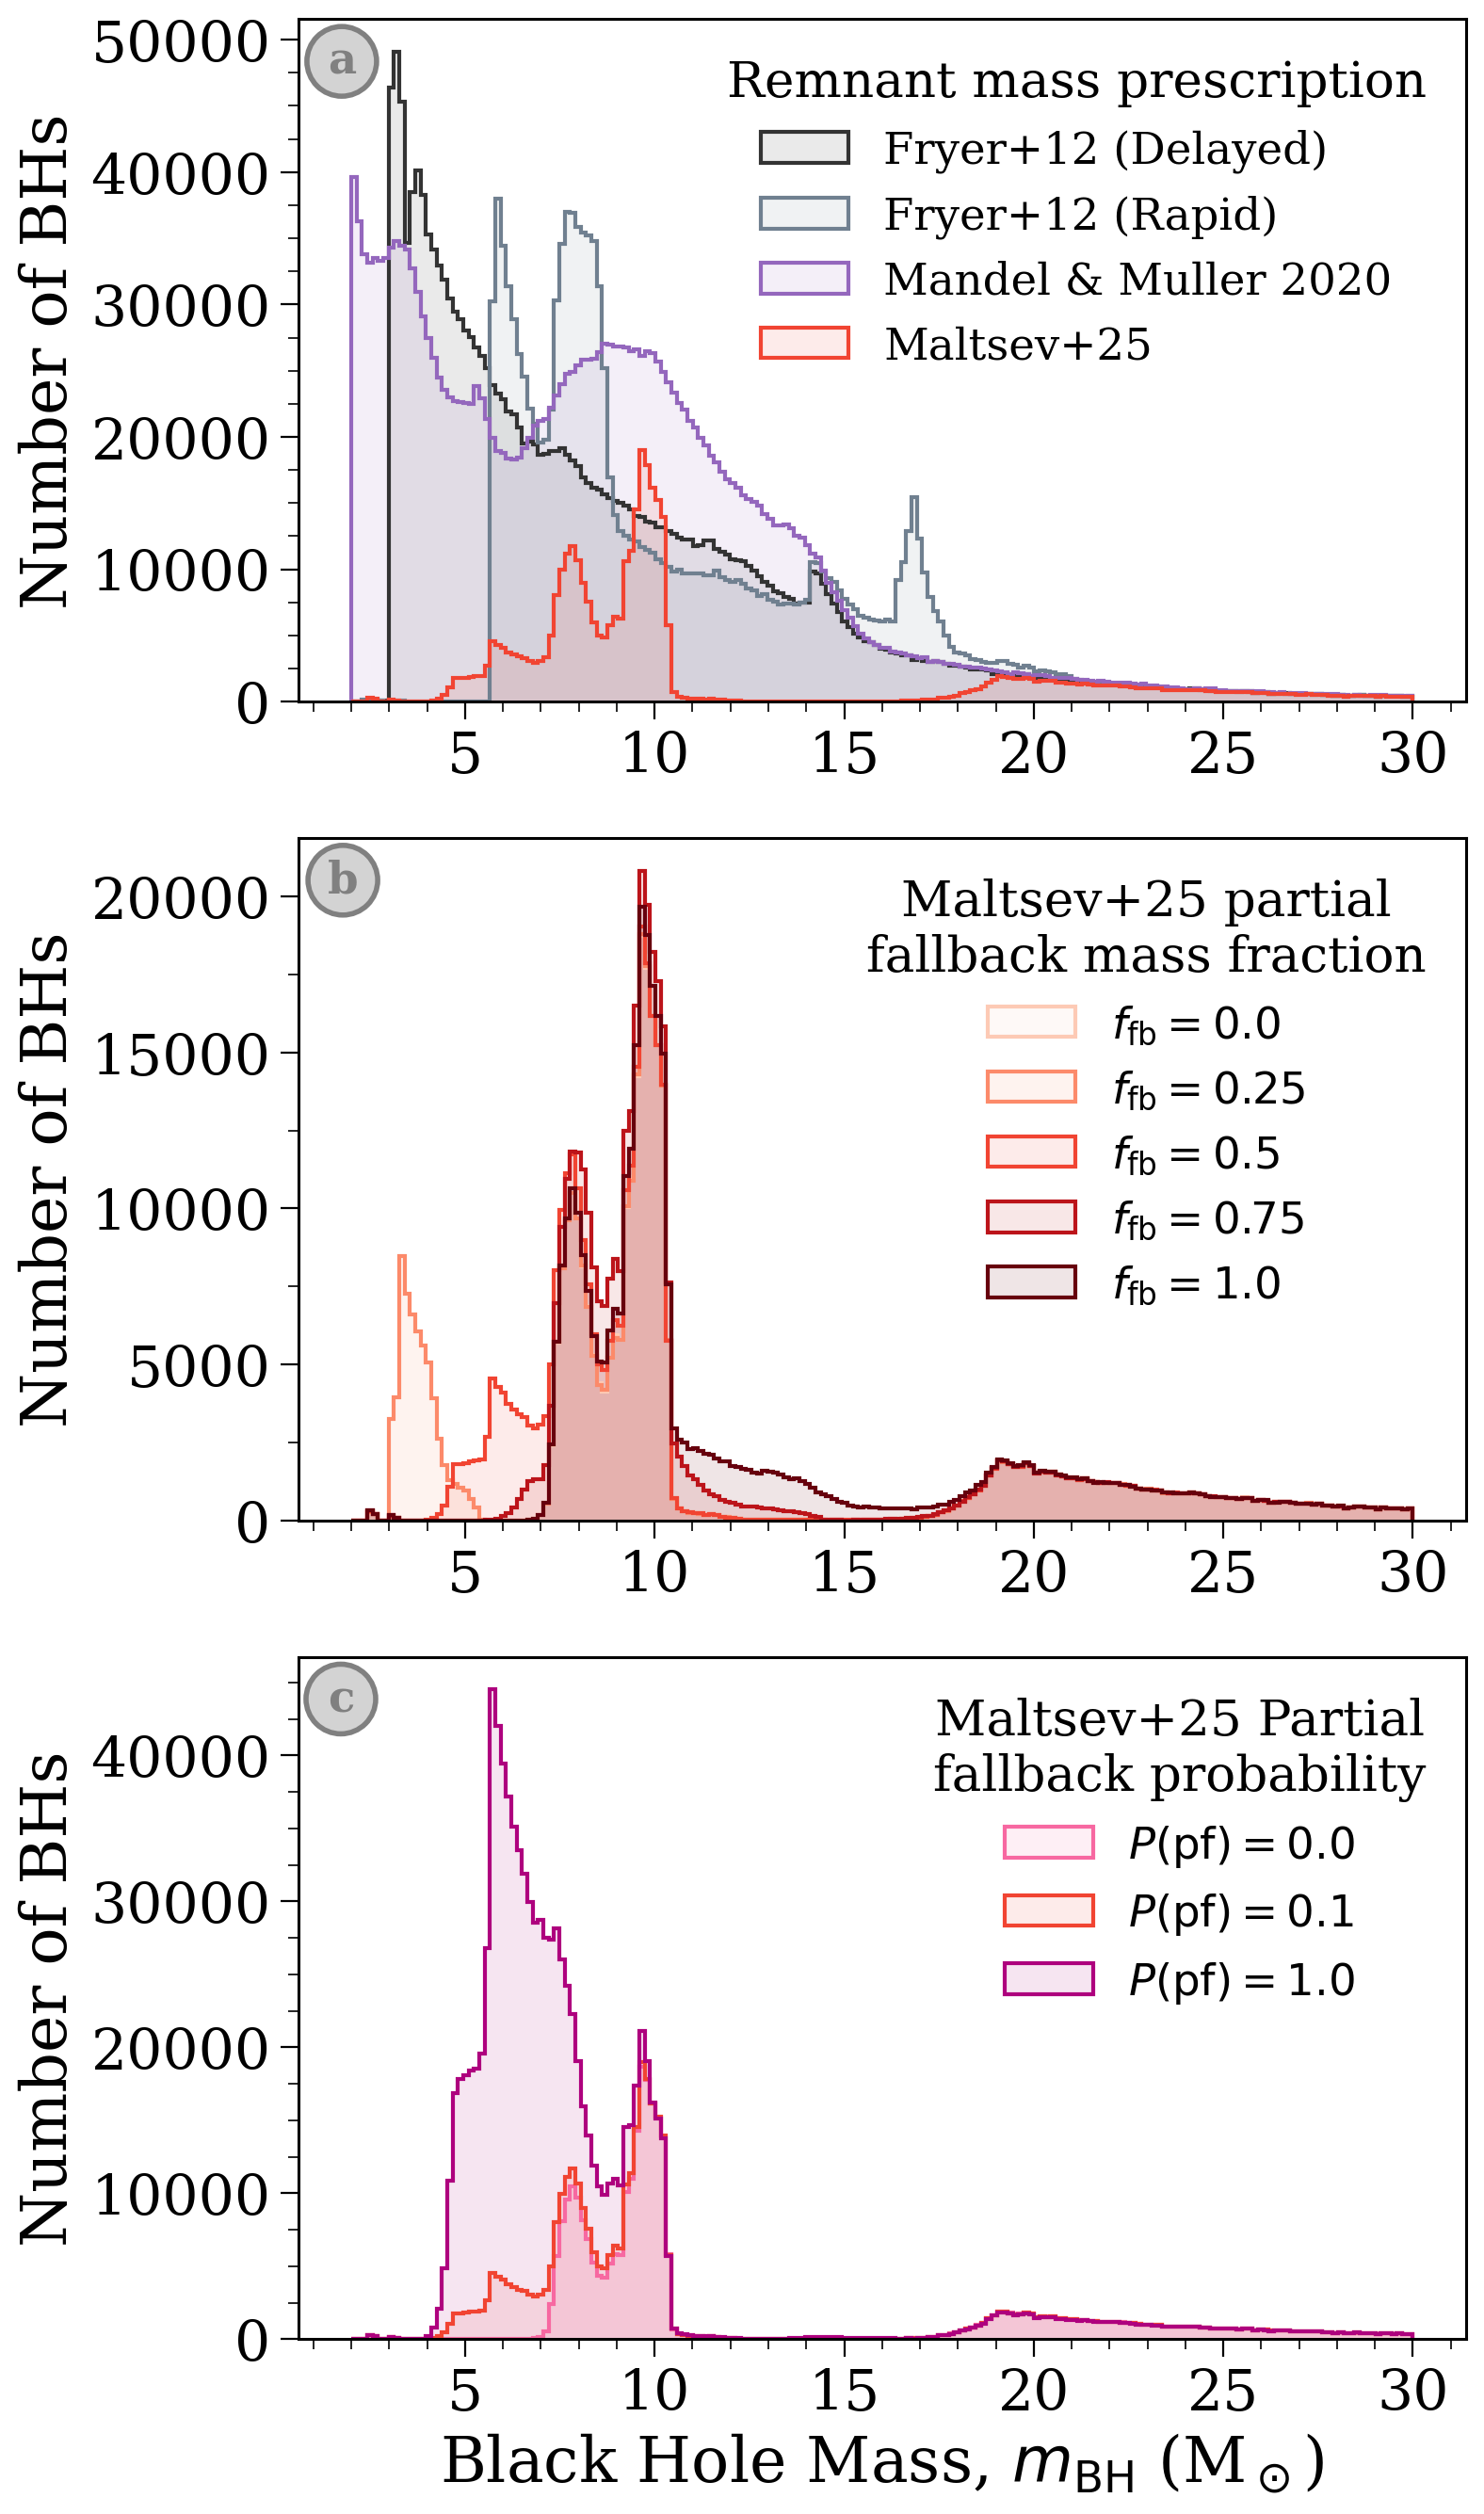

In [53]:
reload(plotting)

fig, axes = plt.subplots(3, 1, figsize=(8, 16))

BINS = np.linspace(2, 30, 200)
LW = 1.5

plotting.plot_mass_histogram(
    pops=[p for p in pops if ("Maltsev" not in p.label or "fb}=0.5" in p.label)],
    labels=["Fryer+12 (Delayed)", "Fryer+12 (Rapid)", "Mandel & Muller 2020", "Maltsev+25"],
    data=data,
    bins=BINS,
    co_type="BH",
    xlabel=r"",
    ylabel=r"Number of BHs",
    alpha=0.1,
    legend_title="Remnant mass prescription",
    density=False,
    fig=fig,
    ax=axes[0],
    show=False,
    lw=LW
)

plotting.plot_mass_histogram(
    pops=[p for p in pops if "fb" in p.label],
    labels=[rf"$f_{{\rm fb}}={f}$" for f in [0.0, 0.25, 0.5, 0.75, 1.0]],
    data=data,
    bins=BINS,
    co_type="BH",
    xlabel=r"",
    ylabel=r"Number of BHs",
    alpha=0.1,
    density=False,
    legend_title="Maltsev+25 partial\nfallback mass fraction",
    fig=fig,
    ax=axes[1],
    show=False,
    lw=LW
)

plotting.plot_mass_histogram(
    pops=[pops[-2], pops[5], pops[-1]],
    labels=[r"$P({\rm pf})=0.0$", r"$P({\rm pf})=0.1$", r"$P({\rm pf})=1.0$"],
    data=data,
    bins=BINS,
    co_type="BH",
    xlabel=r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)",
    ylabel=r"Number of BHs",
    density=False,
    alpha=0.1,
    legend_title="Maltsev+25 Partial\nfallback probability",
    fig=fig,
    ax=axes[2],
    show=False,
    lw=LW
)

for let, ax in zip(["a", "b", "c"], axes):
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(2500))

    ax.annotate(f"{let}", xy=(0.025, 0.97), xycoords='axes fraction', fontsize=0.7*fs, bbox=dict(boxstyle="circle", fc="lightgrey", ec="grey", lw=2), ha='left', va='top', color='grey', fontweight='bold')

plt.savefig("../plots/bh_mass_rm_variations.pdf", format="pdf", bbox_inches='tight')
plt.show()

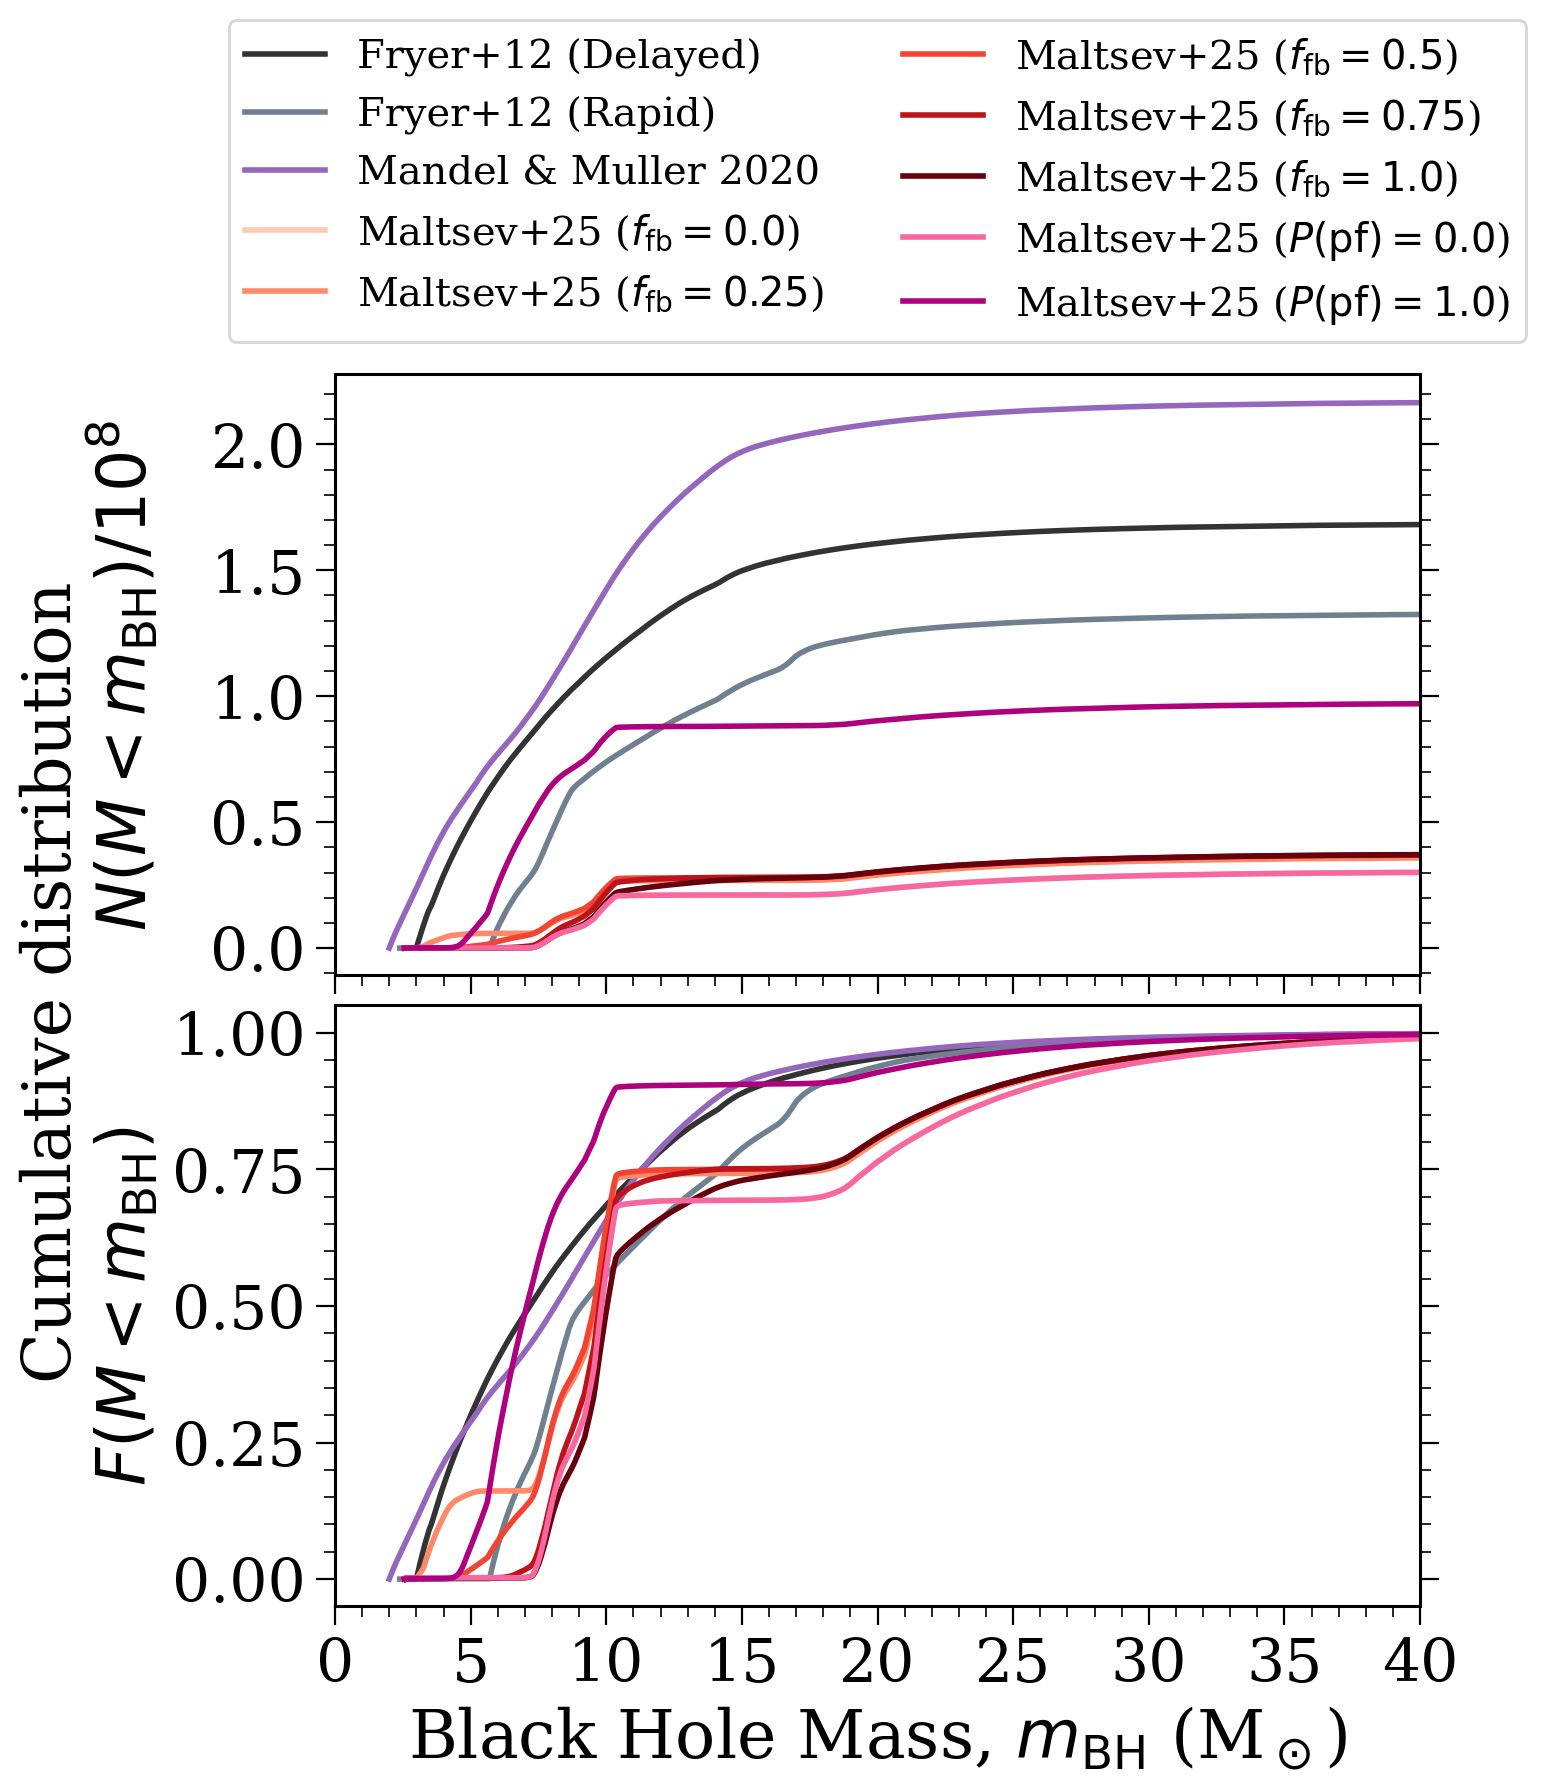

In [62]:
reload(plotting)

fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

fig.subplots_adjust(hspace=0.05)

LW = 1.5

for ax, density in zip(axes, [False, True]):

    # construct an empirical CDF from the mass data (no bins)
    for pop in pops:
        mass = data[pop.label]["mass"]["BH"][~data[pop.label]["escaped"]["BH"]]
        sorted_mass = np.sort(mass)
        cdf = np.arange(1, len(sorted_mass)+1) / len(sorted_mass)
        factor = (len(mass) / 1e8 * 6e10 / data[pop.label]["mass_binaries"]) if not density else 1
        ax.plot(sorted_mass, cdf * factor, label=pop.label, color=pop.colour, alpha=1.0, lw=2)

for ax in axes:
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
    ax.yaxis.set_ticks_position('both')
    ax.set_xlim(0, 40)

axes[0].set_ylabel(r"$N(M<m_{\rm BH}) / 10^8$")
axes[1].set_ylabel(r"$F(M<m_{\rm BH})$")
axes[-1].set_xlabel(r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)")

axes[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
axes[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))

axes[0].legend(loc="lower center", fontsize=0.6 * fs, ncol=2, bbox_to_anchor=(0.5, 1.02))

fig.align_ylabels()

fig.supylabel(r"Cumulative distribution", fontsize=fs, x=-0.1)

plt.savefig("../plots/bh_mass_rmp_cdfs.pdf", format="pdf", bbox_inches='tight')
plt.show()

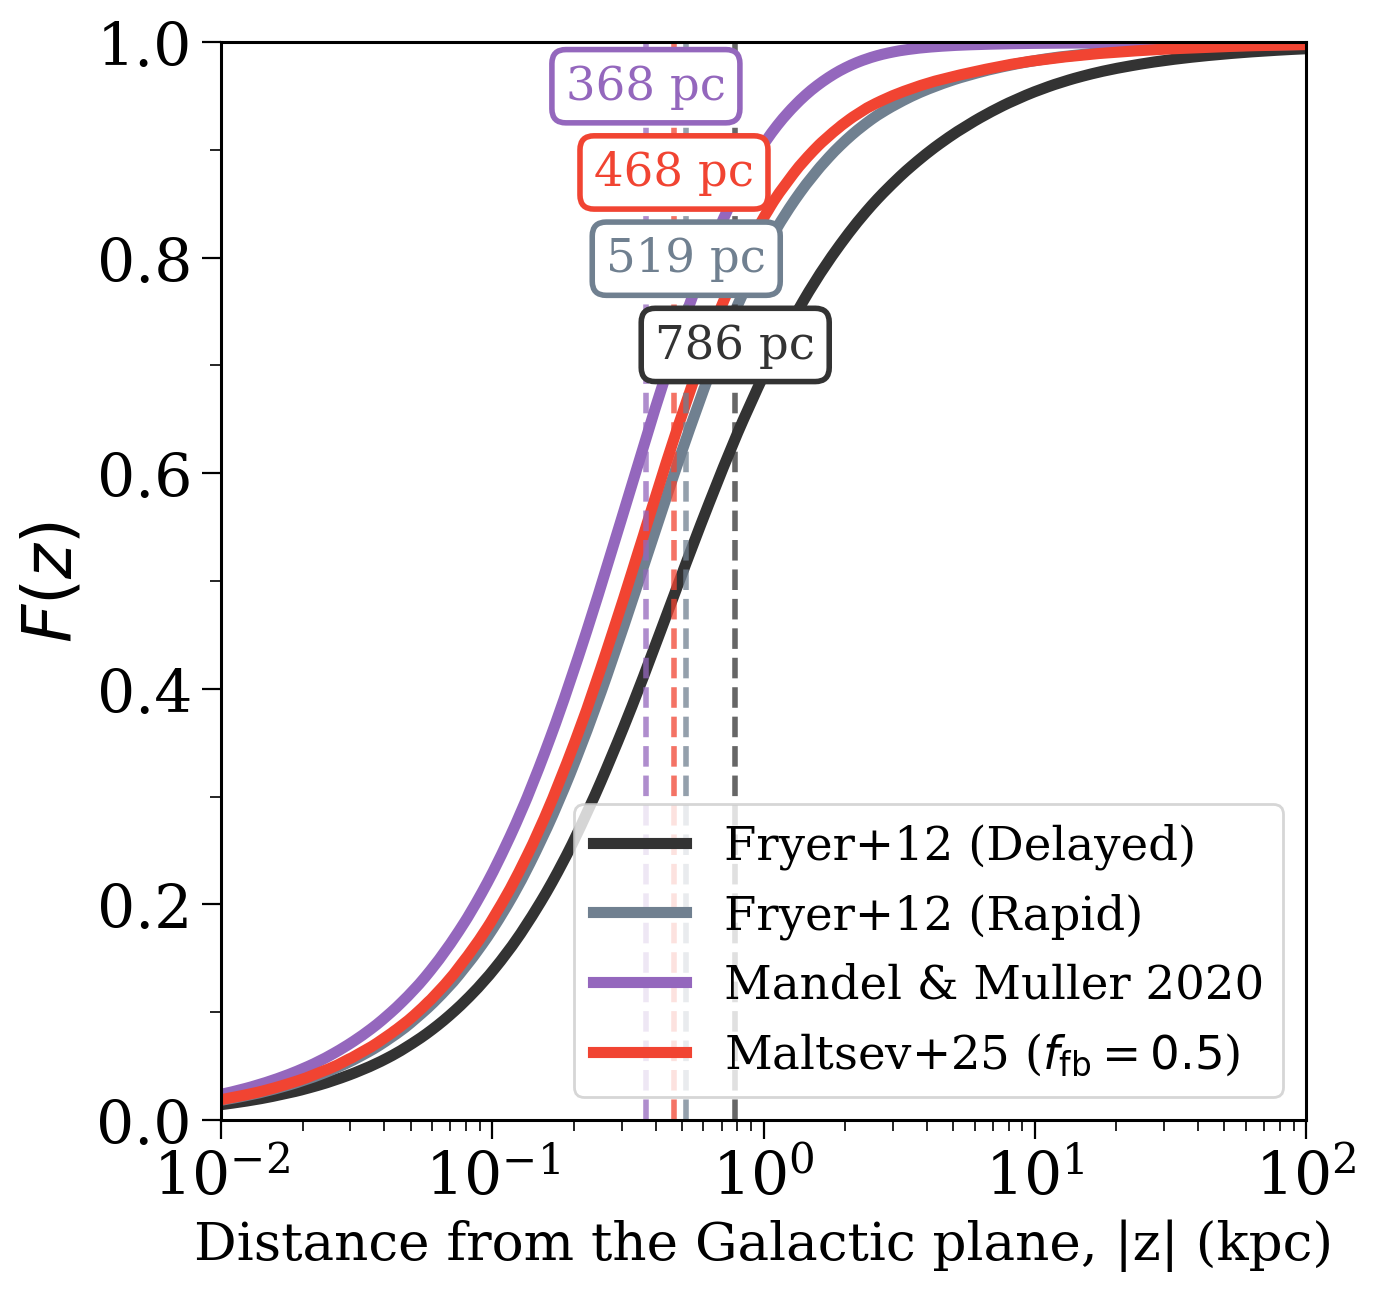

In [5]:
reload(plotting)
fig, ax = plt.subplots(figsize=(7, 7))

sep = 0.08
for pop, loc in zip([pops[0], pops[1], pops[2], pops[5]], [0.98 - sep * 3, 0.98 - sep * 2, 0.98 - sep * 0, 0.98 - sep * 1]):
    plotting.estimate_scale_height_cdf(
        z=data[pop.label]["pos"]["BH"][:, 2][~data[pop.label]["escaped"]["BH"]],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-2, 1e2),
        ylim=(0, 1),
        scale_height_loc=loc
    )


# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

plt.savefig("../plots/scale_height_rmp.pdf", format="pdf", bbox_inches="tight")

plt.show()

Inner 10 kpc
  Fryer+12 (Delayed) fraction within 0.5 kpc 0.53
  Fryer+12 (Rapid) fraction within 0.5 kpc 0.63
  Mandel & Muller 2020 fraction within 0.5 kpc 0.74
  Maltsev+25 ($f_{\rm fb}=0.0$) fraction within 0.5 kpc 0.72
  Maltsev+25 ($f_{\rm fb}=0.25$) fraction within 0.5 kpc 0.67
  Maltsev+25 ($f_{\rm fb}=0.5$) fraction within 0.5 kpc 0.67
  Maltsev+25 ($f_{\rm fb}=0.75$) fraction within 0.5 kpc 0.68
  Maltsev+25 ($f_{\rm fb}=1.0$) fraction within 0.5 kpc 0.71
  Maltsev+25 ($P({\rm pf})=0.0$) fraction within 0.5 kpc 0.72
  Maltsev+25 ($P({\rm pf})=1.0$) fraction within 0.5 kpc 0.51
Full population
  Fryer+12 (Delayed) fraction within 0.5 kpc 0.49
  Fryer+12 (Rapid) fraction within 0.5 kpc 0.62
  Mandel & Muller 2020 fraction within 0.5 kpc 0.74
  Maltsev+25 ($f_{\rm fb}=0.0$) fraction within 0.5 kpc 0.71
  Maltsev+25 ($f_{\rm fb}=0.25$) fraction within 0.5 kpc 0.64
  Maltsev+25 ($f_{\rm fb}=0.5$) fraction within 0.5 kpc 0.65
  Maltsev+25 ($f_{\rm fb}=0.75$) fraction within 0.5 kpc

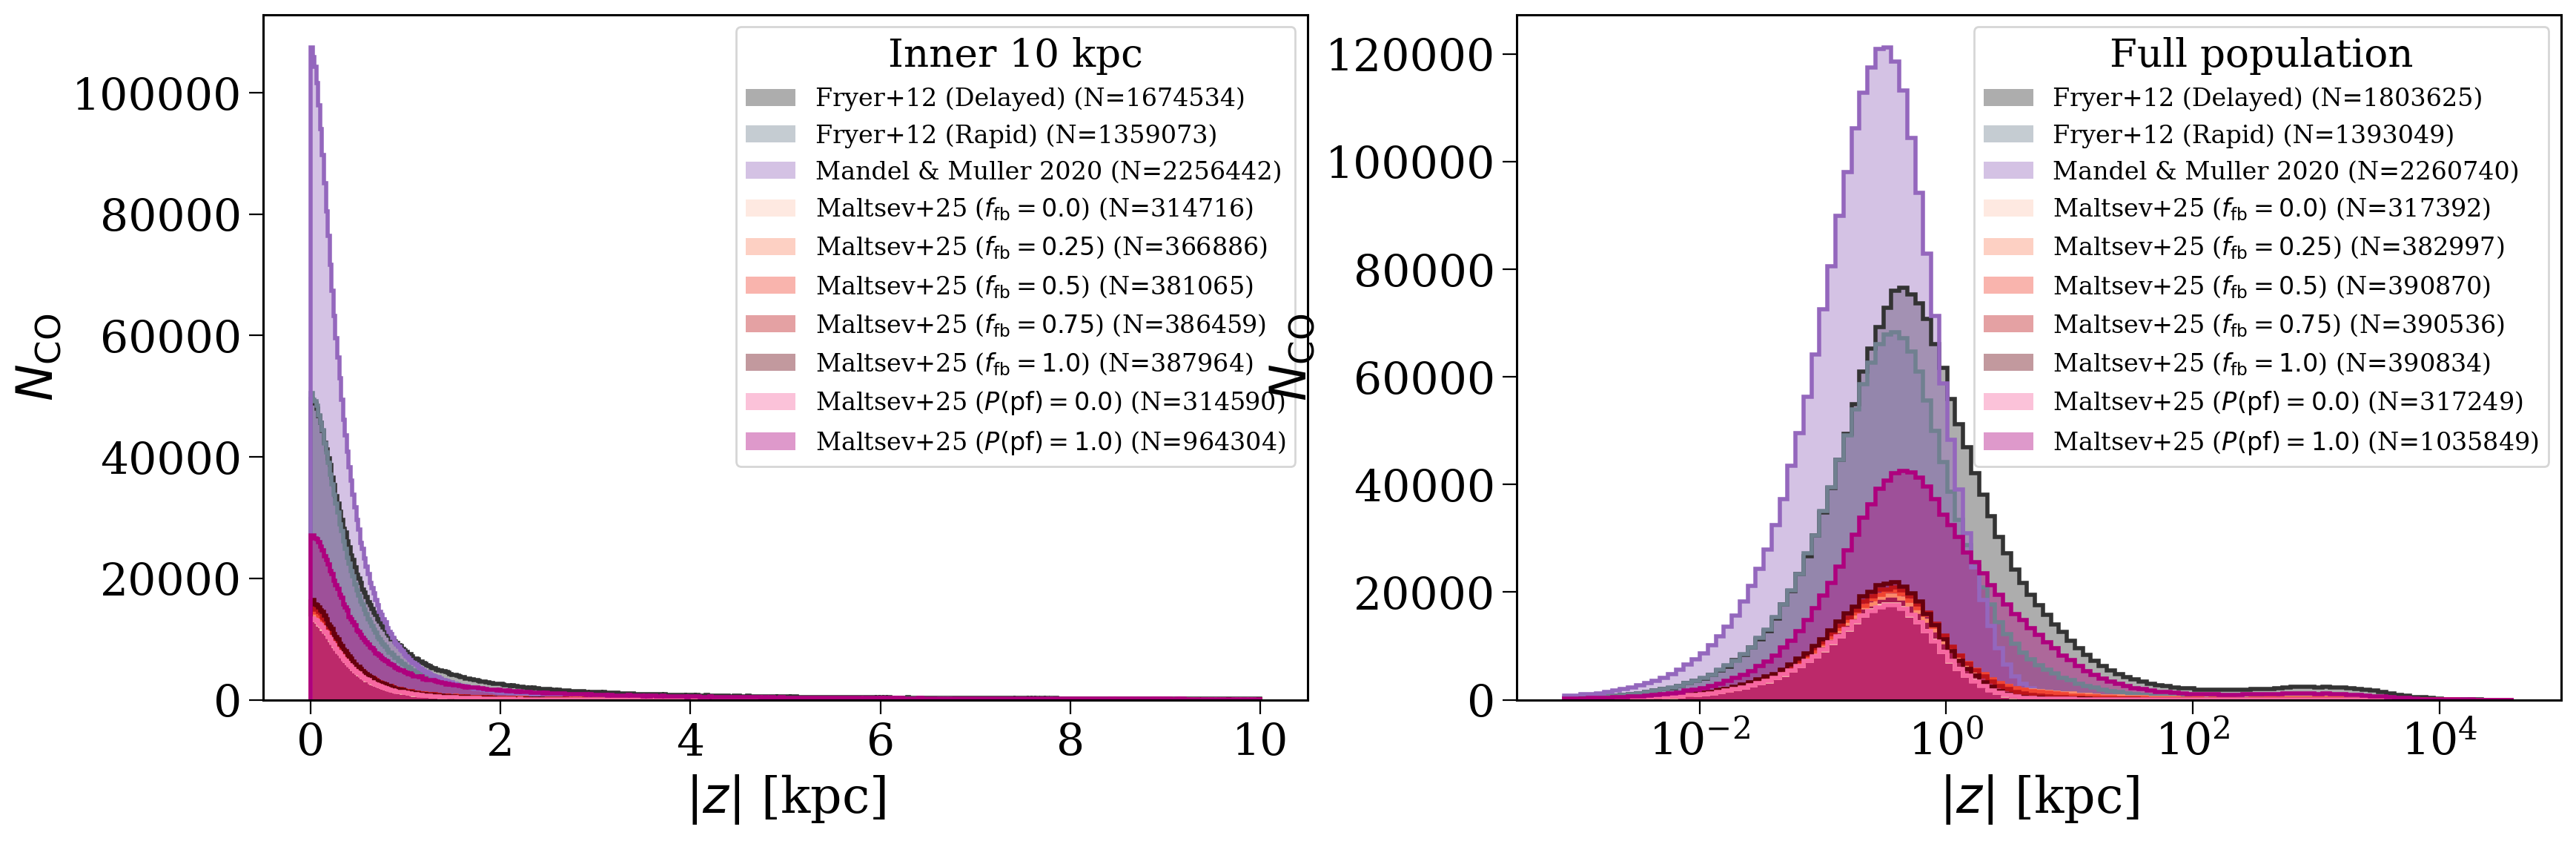

(<Figure size 2000x600 with 2 Axes>,
 array([<Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>,
        <Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>], dtype=object))

In [7]:
plotting.absolute_galactocentric_height(pops, data, co_type="BH")

In [8]:
z_range = np.geomspace(0.05, 10, 250)

abs_zs = [np.abs(data[pop.label]["pos"]["BH"][:, 2]) for pop in pops]

mean_masses = helpers.get_average_mass_at_z(
    abs_zs=abs_zs + [np.abs(data["Fryer+12 (Delayed)"]["init_z"]["BH"])],
    bh_masses=[data[pop.label]["mass"]["BH"] for pop in pops] + [data["Fryer+12 (Delayed)"]["mass"]["BH"]],
    z_range=z_range,
    window_width=0.25,
    average_function=np.median
)

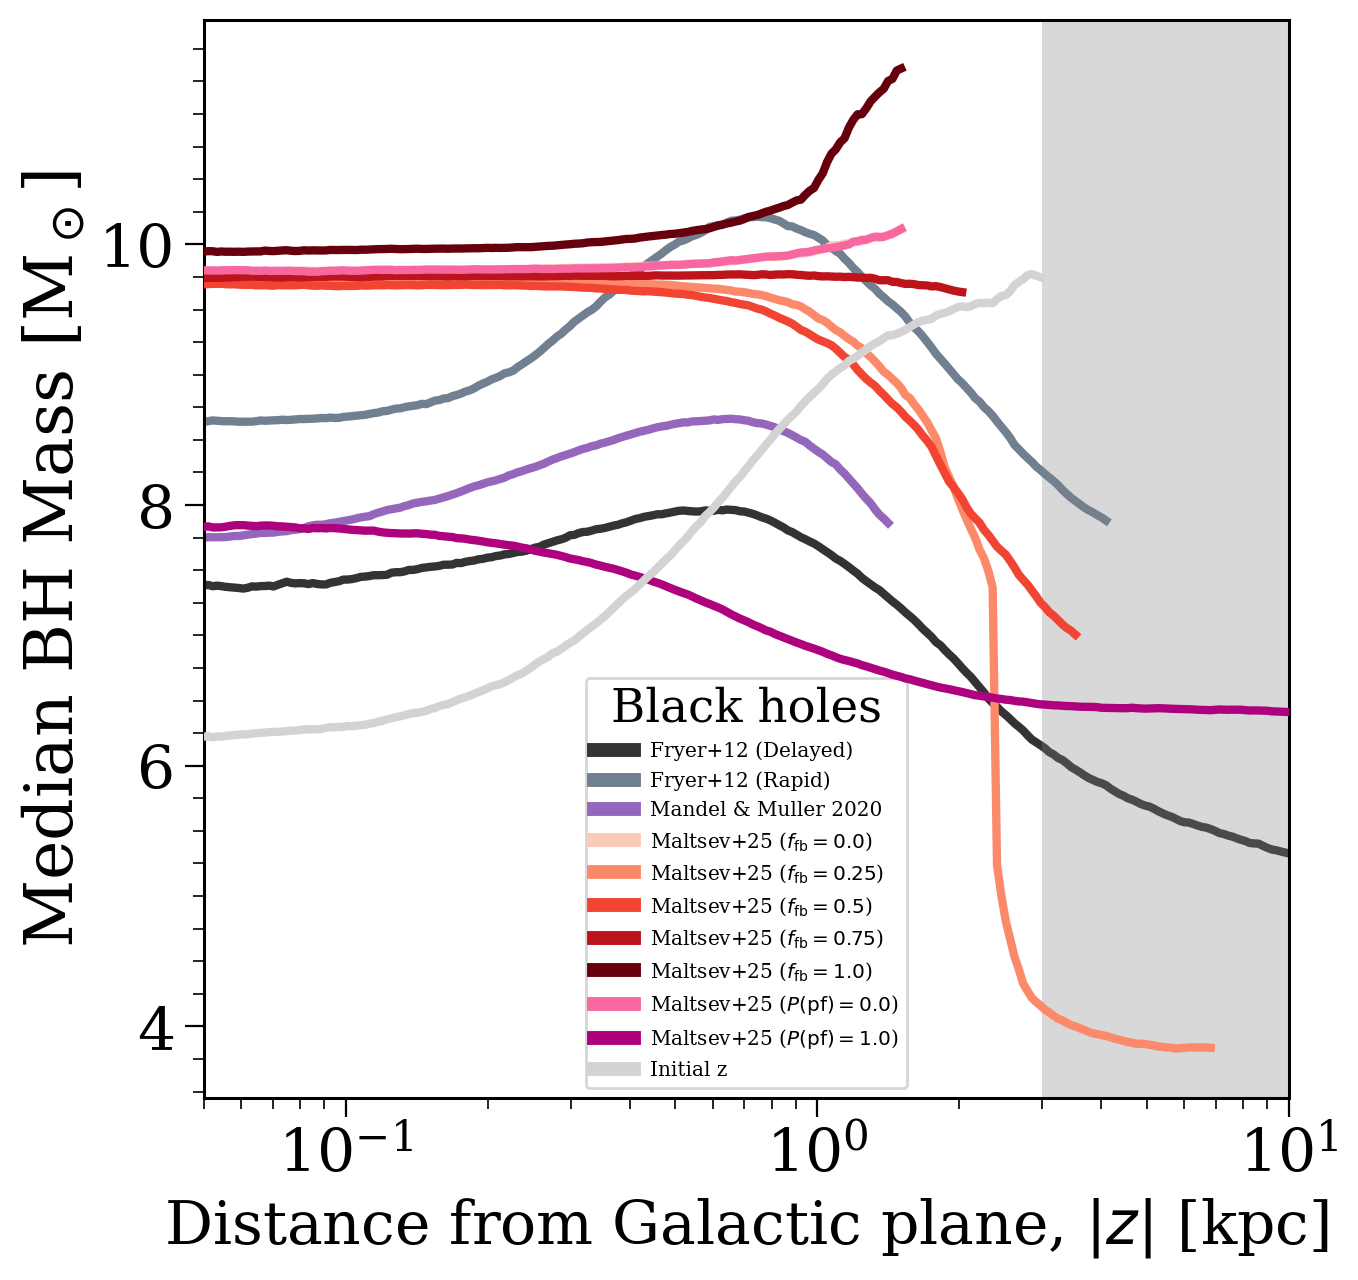

(<Figure size 700x700 with 1 Axes>,
 <Axes: xlabel='Distance from Galactic plane, $|z|$ [kpc]', ylabel='Median BH Mass [M$_\\odot$]'>)

In [13]:
plotting.plot_avg_mass_vs_z(
    mean_masses=mean_masses, labels=[pop.label for pop in pops] + ["Initial z"], colours=[pop.colour for pop in pops] + ["lightgrey"],
    z_maxes=[np.percentile(abs_zs[i], 95) for i in range(len(pops))] + [3], z_range=z_range,
    legend_kwargs={
        "fontsize": 0.3 * fs
    }
)

In [ ]:
def plot_mass_directions(pop, data, co_type="BH", bins=np.linspace(3, 30, 50), fig=None, ax=None, show=True,
                         mc_deg_sep=20, bulge_z_sep=0.5, bulge_r_sep=8.2,
                         **kwargs):
    from astropy.coordinates import SkyCoord
    import astropy.units as u
    if fig is None or ax is None:
        fig, ax = plt.subplots()
    
    # MW microlensing mask
    near_plane = abs(data[pop.label]["pos"]["BH"][:, 2]) < bulge_z_sep
    between_sun_center = np.linalg.norm(data[pop.label]["pos"]["BH"][:, :2], axis=1) < bulge_r_sep
    mw_bulge_mask = near_plane & between_sun_center

    coords = SkyCoord(
        x=data[pop.label]["pos"][co_type][:, 0] * u.kpc,
        y=data[pop.label]["pos"][co_type][:, 1] * u.kpc,
        z=data[pop.label]["pos"][co_type][:, 2] * u.kpc,
        frame="galactocentric",
    ).icrs

    # mask on those that are in the direction magellanic clouds
    lmc = SkyCoord(ra=80.89416667*u.deg, dec=-69.75611111*u.deg)
    smc = SkyCoord(ra=13.15833333*u.deg, dec=-72.80027778*u.deg)
    sep_lmc = coords.separation(lmc)
    sep_smc = coords.separation(smc)
    close_to_lmc = (sep_lmc < mc_deg_sep*u.deg) & (coords.distance < 50*u.kpc)
    close_to_smc = (sep_smc < mc_deg_sep*u.deg) & (coords.distance < 70*u.kpc)

    mc_mask = close_to_lmc | close_to_smc

    # define a mask that's a cone going straight up/down from the sun
    # CONE_DEGS = 15
    # sun_direction = SkyCoord(ra=0*u.deg, dec=90*u.deg)
    # sep_sun = coords.separation(sun_direction)
    # cone_mask = (sep_sun < CONE_DEGS*u.deg)
    # sun_direction = SkyCoord(ra=0*u.deg, dec=-90*u.deg)
    # sep_sun = coords.separation(sun_direction)
    # cone_mask |= (sep_sun < CONE_DEGS*u.deg)

    for mask, label, c in zip([mw_bulge_mask, mc_mask], ["Towards MW bulge", "Towards MC Clouds"], ["tab:blue", "tab:orange"]):
        print(mask.sum())
        plotting.nice_transparent_hist(
            ax=ax, data=data[pop.label]["mass"][co_type][mask],
            colour=c,
            bins=bins, density=True, label=label, alpha=0.5, lw=2
        )

    ax.legend()

    ax.set(
        xlabel=kwargs.pop("xlabel", f"Mass of {co_type} [M$_\odot$]"),
        ylabel=kwargs.pop("ylabel", "Density"),
        **kwargs
    )

    if show:
        plt.show()
    return fig, ax

559700
12907
547723
6100
1117975
4142
146722
1478


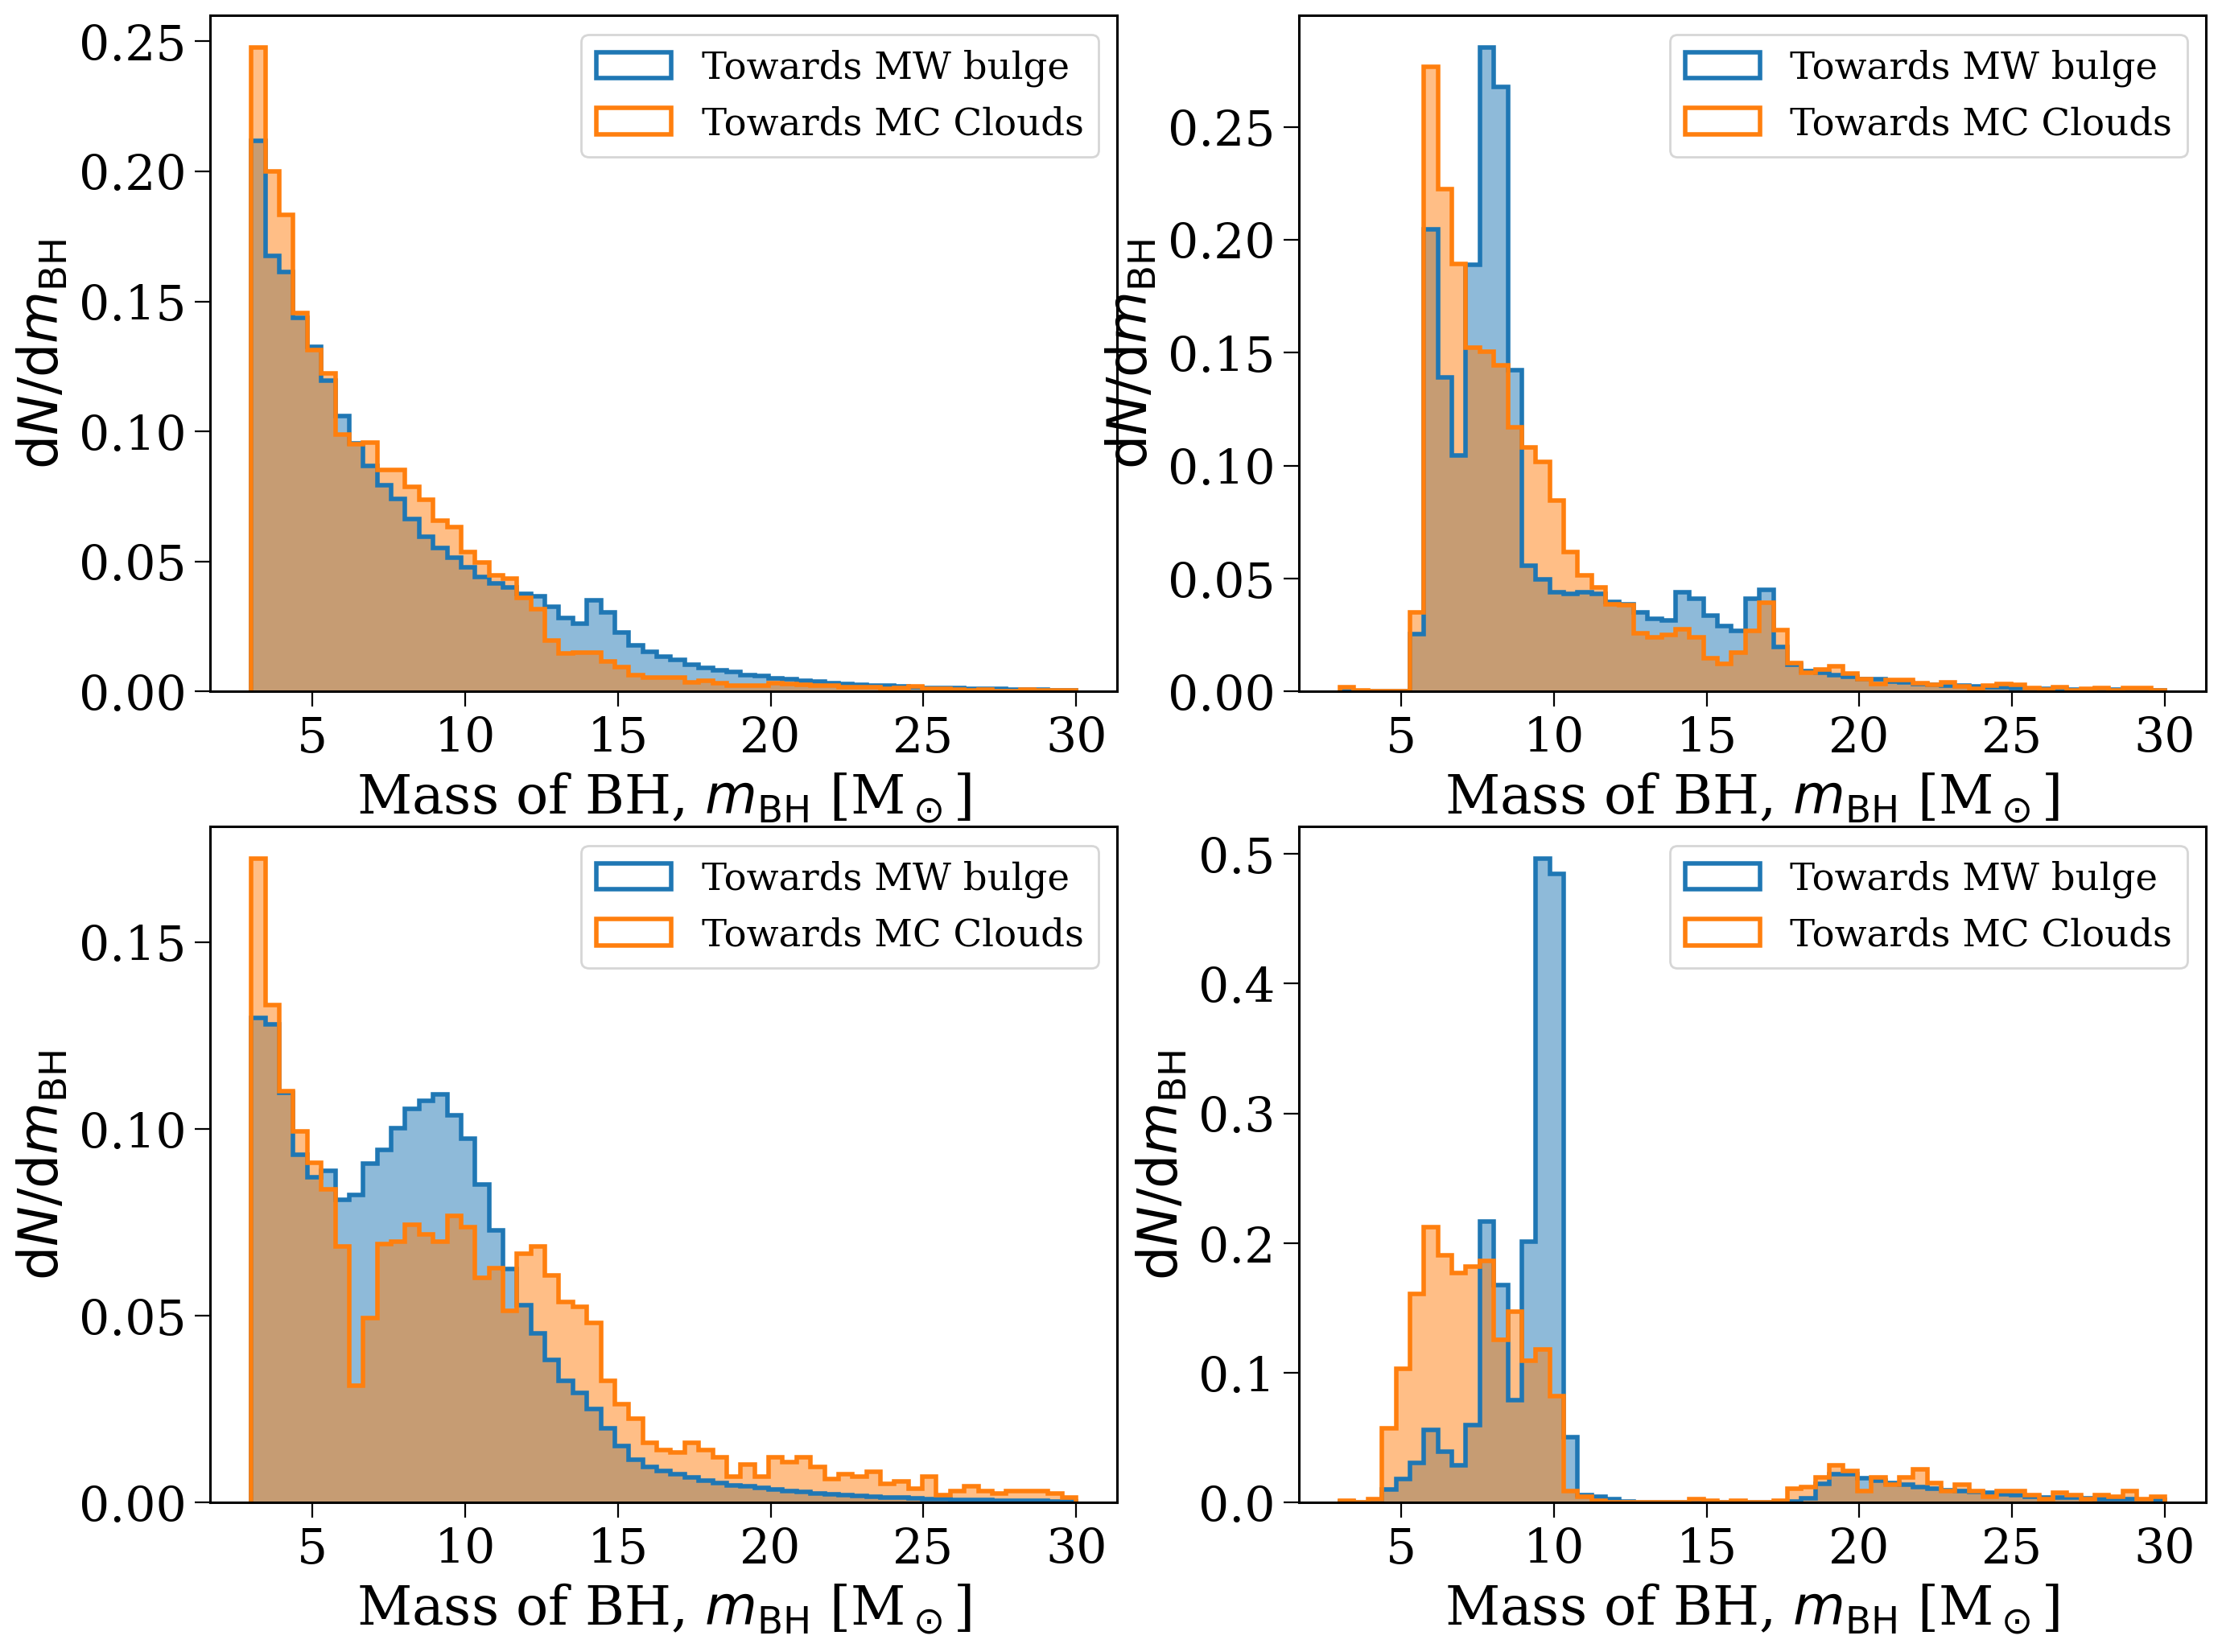

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax_list = axes.flatten()
i = 0

for pop in pops:
    if pop.label.startswith("Maltsev") and "0.5" not in pop.label:
        continue
    ax = ax_list[i]
    plot_mass_directions(pop, data, bins=np.linspace(3, 30, 60),
                         xlabel=r"Mass of BH, $m_{\rm BH}$ [M$_\odot$]",
                         ylabel=r"${\rm d}N/{\rm d}m_{\rm BH}$",
                         ax=ax, fig=fig, show=False)
    
    i += 1
plt.show()